# batch_demo visualization

Loads the per-batch dumps from `dump_batch/` (project root) produced by `batch_demo` (B=4) and shows the inputs and outputs side-by-side. Outputs are R = conv(E,Gx)·dI/dx + conv(E,Gy)·dI/dy, valid region only.

Storage convention is ArrayFire-style column-major (`data[r + c*H]`); the dump file format is still one line per image row, so `np.loadtxt` returns `(H, W)` arrays indexed `arr[r, c]` as usual.

Run `./build/batch_demo` from the project root first to regenerate the dumps.

In [36]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Works whether Jupyter CWD is the project root or the notebooks/ subdirectory.
_cwd = Path(os.path.abspath(''))
_candidates = [_cwd / 'dump_batch', _cwd.parent / 'dump_batch']
DUMP = next((p for p in _candidates if p.exists()), _candidates[-1])
print('DUMP:', DUMP)

B = 4

def load(name):
    return np.loadtxt(DUMP / name, comments='#')

Es = [load(f'b{b}_E.txt') for b in range(B)]
Is = [load(f'b{b}_I.txt') for b in range(B)]
Rs = [load(f'b{b}_R.txt') for b in range(B)]

print('shapes:', Es[0].shape, Is[0].shape, Rs[0].shape)

DUMP: /home/kyp/Workspace/01.libraries/shrinkage_full_tests/dump_batch
shapes: (256, 256) (256, 256) (134, 134)


gamma=0.0500  R_w=60.00 pixels  cx=cy=15
KW=31  required >= 2*R_w+1 = 121  → TOO SMALL!
EROSION=15  reference formula ceil(R_w)+1 = 61  → one pixel short


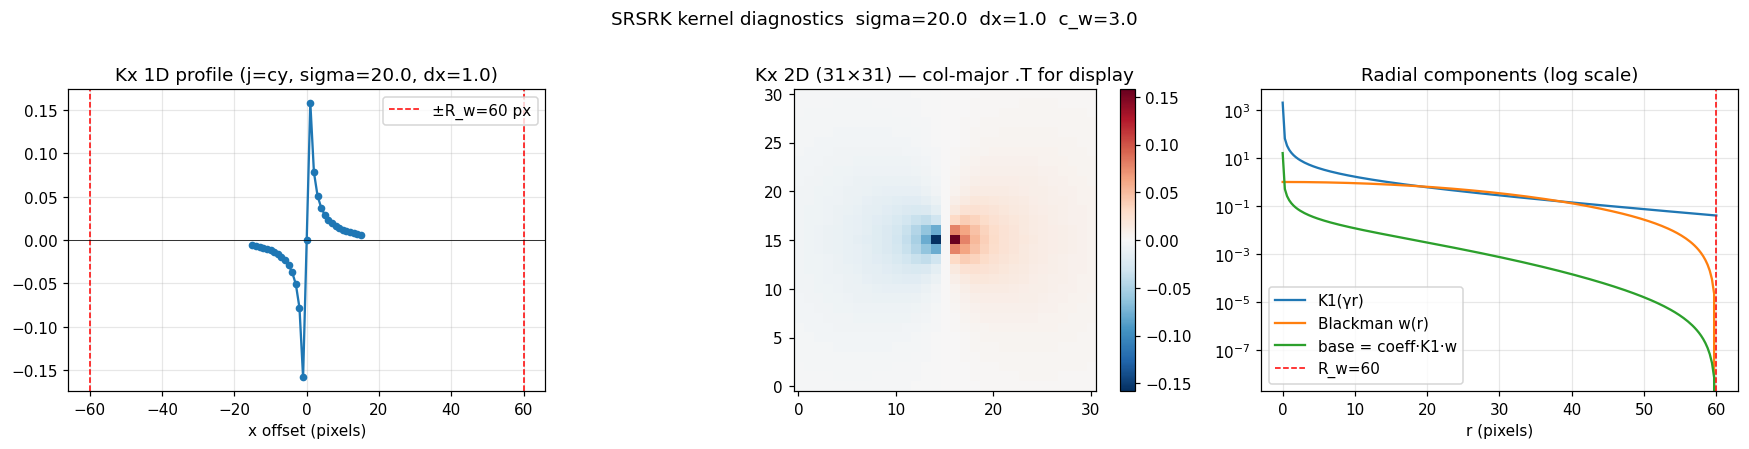


Kx peak (r=1 pixel): 0.1583
Kx at r=R_w edge:    0.00e+00  (should be ~0)
Kx sum (should be 0 by antisymmetry): 0.00e+00


In [37]:
# ── Kernel diagnostic ──────────────────────────────────────────────────────
# Reconstruct Gx / Gy on CPU with the same formula as main_batch_demo.cu
# and verify the Blackman window, support radius, and discrete profile.
import scipy.special as sp

SIGMA    = 20.0
DX       = 1.0
SRSRK_CW = 3.0
KW = KH  = 31

gamma = 1.0 / SIGMA
R_w   = SRSRK_CW / gamma          # = c_w * sigma = 15 pixels
coeff = gamma / (2 * np.pi)
cx, cy = KW // 2, KH // 2

print(f'gamma={gamma:.4f}  R_w={R_w:.2f} pixels  cx=cy={cx}')
print(f'KW={KW}  required >= 2*R_w+1 = {2*R_w+1:.0f}  → {"OK" if KW >= 2*R_w+1 else "TOO SMALL!"}')
print(f'EROSION=15  reference formula ceil(R_w)+1 = {int(np.ceil(R_w))+1}  → one pixel short')

def blackman_radial(r, Rw):
    if r <= 0 or r > Rw:
        return 0.0
    t = r / Rw
    return 0.42 + 0.5 * np.cos(np.pi * t) + 0.08 * np.cos(2 * np.pi * t)

def bessel_K1(x):
    return sp.kv(1, x)

# Build Kx in Python (same col-major layout as C++)
Kx_grid = np.zeros((KW, KH))
Ky_grid = np.zeros((KW, KH))
eps = 1e-6 * DX
for i in range(KW):
    for j in range(KH):
        x = (i - cx) * DX
        y = (j - cy) * DX
        r = np.sqrt(x**2 + y**2)
        if r < eps or r > R_w:
            continue
        w   = blackman_radial(r, R_w)
        K1  = bessel_K1(gamma * r)
        base = coeff * K1 * w
        Kx_grid[i, j] = base * (x / r)
        Ky_grid[i, j] = base * (y / r)

# 1D horizontal profile through centre (j = cy, vary i)
r_vals  = [(i - cx) * DX for i in range(KW)]
Kx_prof = [Kx_grid[i, cy] for i in range(KW)]

fig, axes = plt.subplots(1, 3, figsize=(16, 4), dpi=110)

axes[0].plot(r_vals, Kx_prof, 'o-', ms=4)
axes[0].axvline(-R_w, color='r', ls='--', lw=1, label=f'±R_w={R_w:.0f} px')
axes[0].axvline( R_w, color='r', ls='--', lw=1)
axes[0].axhline(0, color='k', lw=0.5)
axes[0].set_xlabel('x offset (pixels)')
axes[0].set_title(f'Kx 1D profile (j=cy, sigma={SIGMA}, dx={DX})')
axes[0].legend(); axes[0].grid(alpha=0.3)

vmax = np.max(np.abs(Kx_grid))
im1 = axes[1].imshow(Kx_grid.T, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                     origin='lower', interpolation='nearest')
axes[1].set_title(f'Kx 2D (31×31) — col-major .T for display')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

# Radial profile: K1 alone vs full kernel value at same r
rr = np.linspace(0.01, R_w, 200)
axes[2].semilogy(rr, bessel_K1(gamma * rr),         label='K1(γr)')
axes[2].semilogy(rr, [blackman_radial(r, R_w) for r in rr], label='Blackman w(r)')
axes[2].semilogy(rr, coeff * bessel_K1(gamma * rr) *
                     np.array([blackman_radial(r, R_w) for r in rr]),
                 label='base = coeff·K1·w')
axes[2].axvline(R_w, color='r', ls='--', lw=1, label=f'R_w={R_w:.0f}')
axes[2].set_xlabel('r (pixels)'); axes[2].legend(); axes[2].grid(alpha=0.3)
axes[2].set_title('Radial components (log scale)')

plt.suptitle(f'SRSRK kernel diagnostics  sigma={SIGMA}  dx={DX}  c_w={SRSRK_CW}', y=1.01)
plt.tight_layout()
plt.show()

print(f'\nKx peak (r=1 pixel): {Kx_grid[cx+1, cy]:.4f}')
print(f'Kx at r=R_w edge:    {Kx_grid[cx, cy]:.2e}  (should be ~0)')
print(f'Kx sum (should be 0 by antisymmetry): {Kx_grid.sum():.2e}')

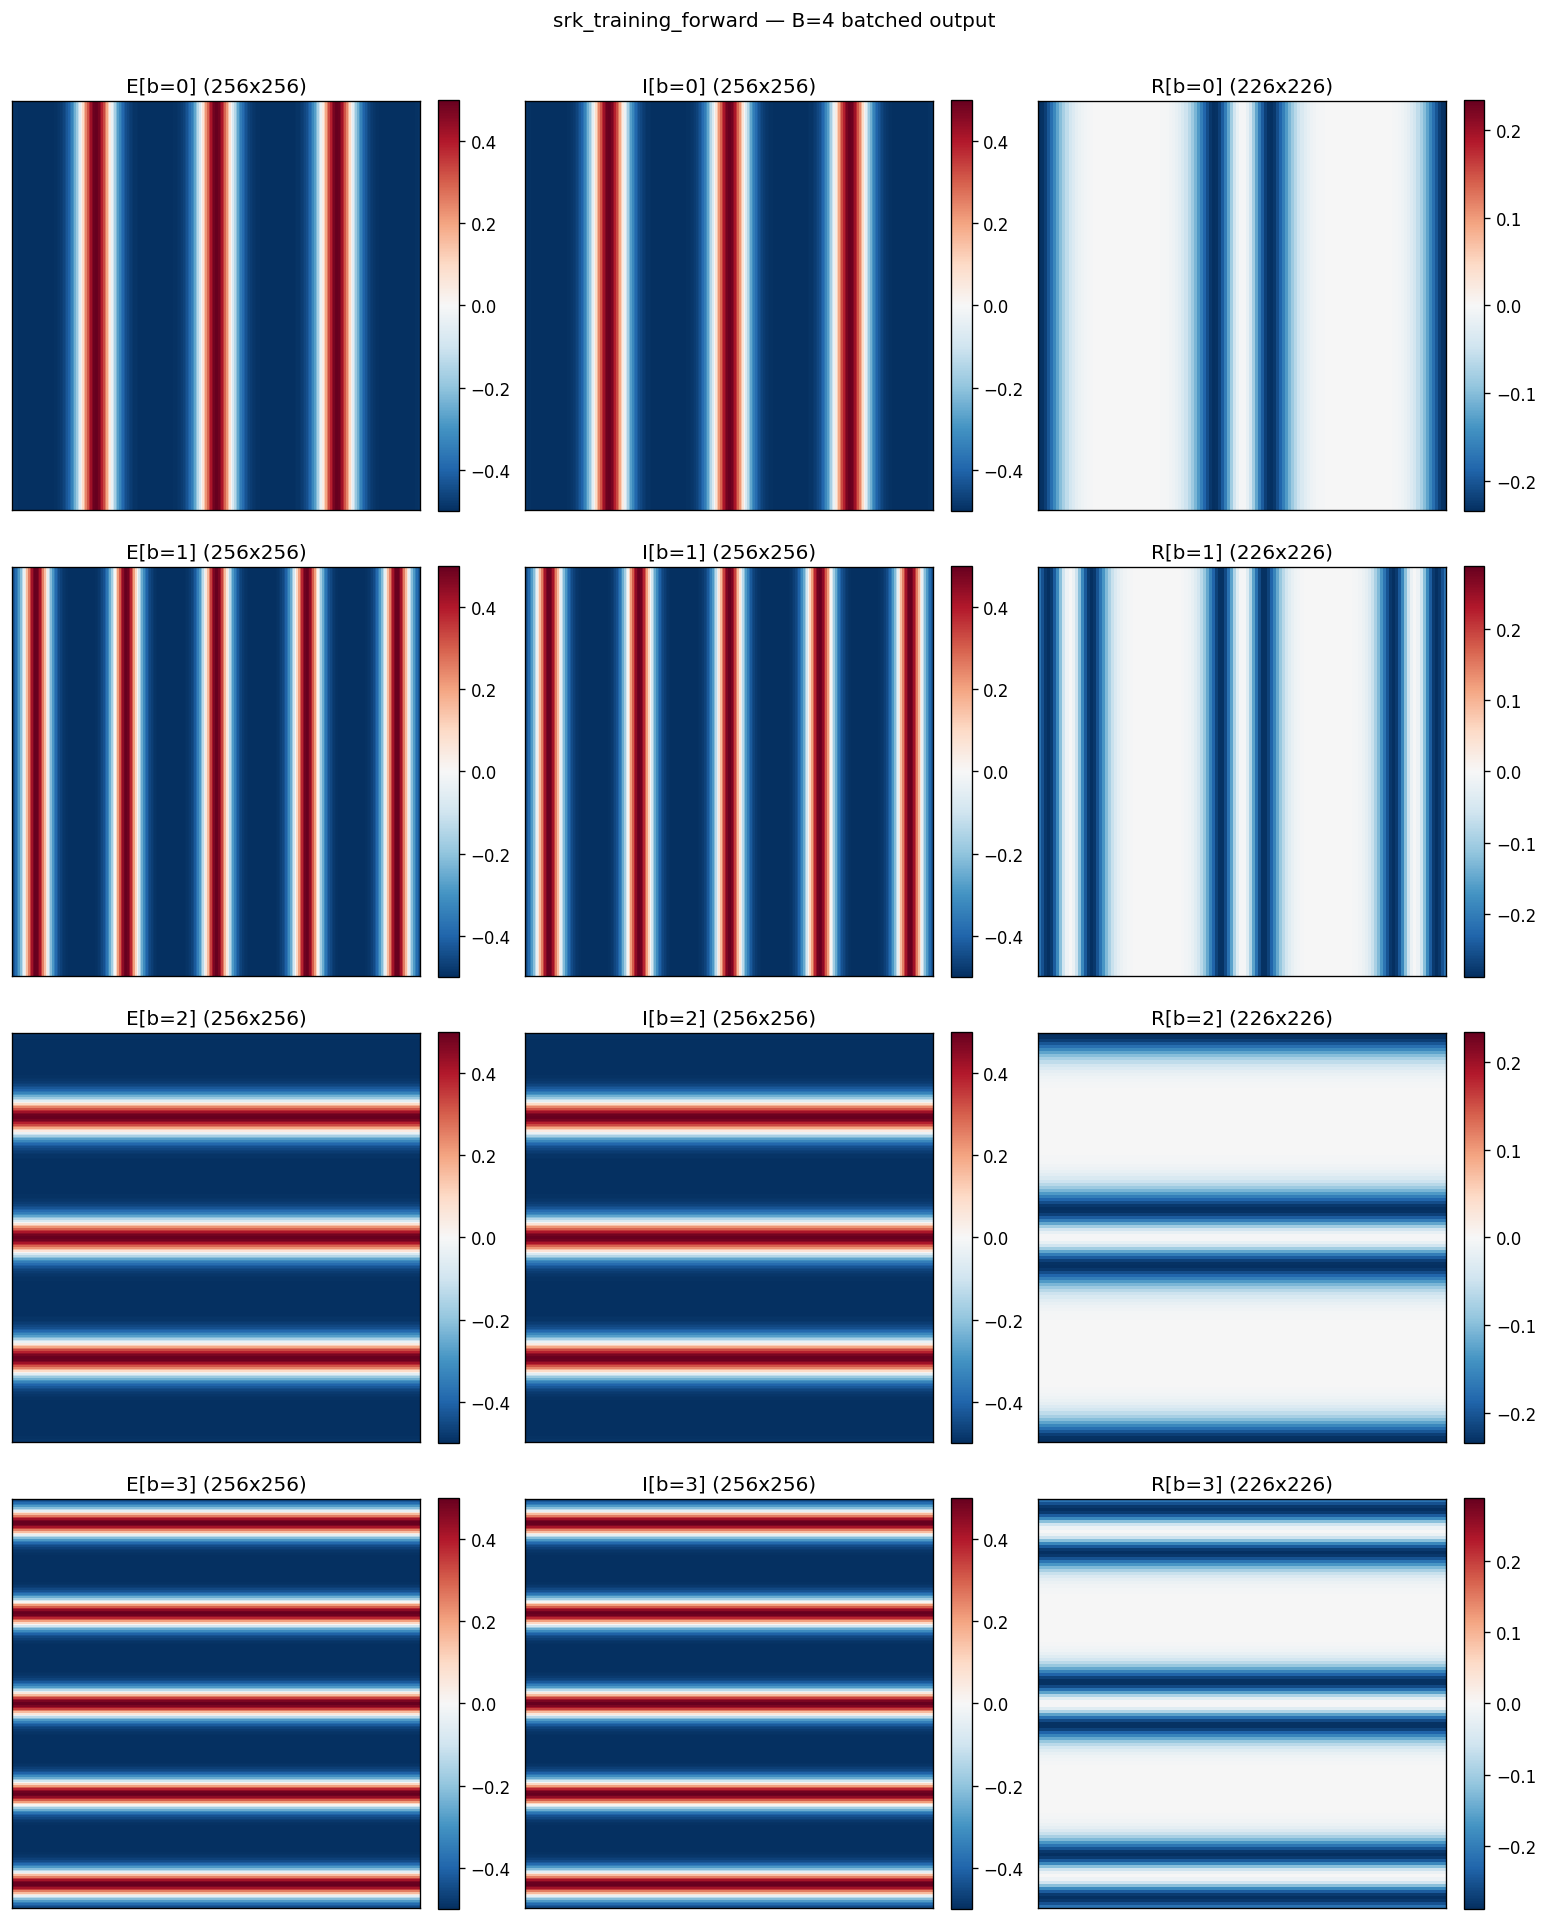

In [38]:
# Use interpolation='nearest' so each data pixel maps to display pixels 1:1.
# Without this, imshow's antialiased downsampling produces moiré patterns
# that look like wraparound artifacts but are purely a rendering effect.
fig, ax = plt.subplots(B, 3, figsize=(13, 4 * B), dpi=120)
for b in range(B):
    for col, (img, title) in enumerate(zip(
        [Es[b], Is[b], Rs[b]],
        [f'E[b={b}] (256x256)', f'I[b={b}] (256x256)', f'R[b={b}] (226x226)'])):
        a = ax[b, col]
        m = np.max(np.abs(img))
        im = a.imshow(img, cmap='RdBu_r', vmin=-m, vmax=m, interpolation='nearest')
        a.set_title(title)
        a.set_xticks([]); a.set_yticks([])
        fig.colorbar(im, ax=a, fraction=0.046, pad=0.04)
fig.suptitle('srk_training_forward — B=4 batched output', y=1.001)
fig.tight_layout()
plt.show()

In [39]:
# Per-batch stats
for b in range(B):
    print(f'b={b}  R: shape={Rs[b].shape}  min={Rs[b].min():+.3f}  max={Rs[b].max():+.3f}  mean={Rs[b].mean():+.3e}  std={Rs[b].std():.3e}')

b=0  R: shape=(134, 134)  min=-0.234  max=-0.000  mean=-6.484e-02  std=8.204e-02
b=1  R: shape=(134, 134)  min=-0.288  max=-0.000  mean=-1.029e-01  std=1.074e-01
b=2  R: shape=(134, 134)  min=-0.234  max=-0.000  mean=-6.484e-02  std=8.204e-02
b=3  R: shape=(134, 134)  min=-0.288  max=-0.000  mean=-1.029e-01  std=1.074e-01


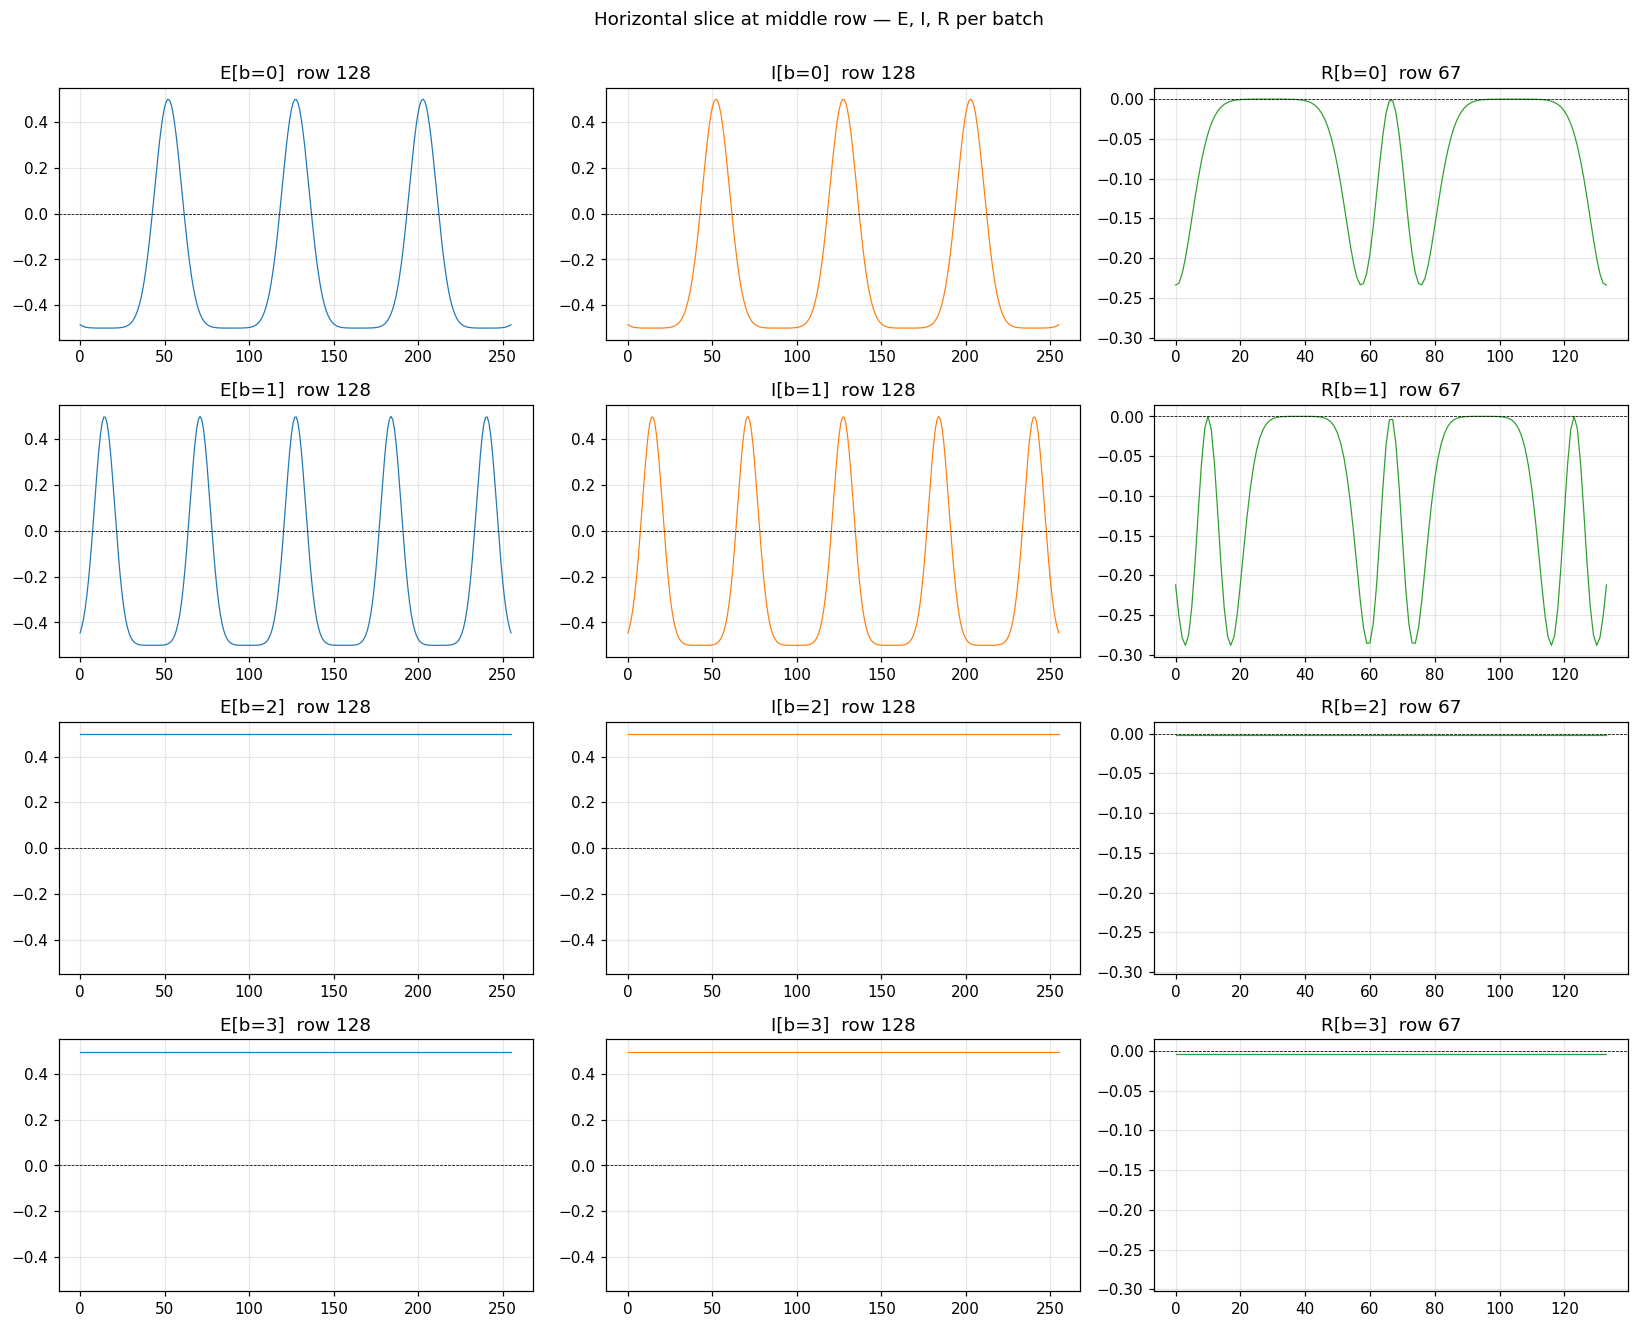

In [40]:
# Horizontal 1D slice through the middle row of each batch
fig, axes = plt.subplots(B, 3, figsize=(15, 3 * B), dpi=110, sharey='col')
for b in range(B):
    mid_E = Es[b].shape[0] // 2
    mid_R = Rs[b].shape[0] // 2
    axes[b, 0].plot(Es[b][mid_E, :], lw=0.8)
    axes[b, 0].set_title(f'E[b={b}]  row {mid_E}')
    axes[b, 1].plot(Is[b][mid_E, :], lw=0.8, color='tab:orange')
    axes[b, 1].set_title(f'I[b={b}]  row {mid_E}')
    axes[b, 2].plot(Rs[b][mid_R, :], lw=0.8, color='tab:green')
    axes[b, 2].set_title(f'R[b={b}]  row {mid_R}')
    for ax in axes[b]:
        ax.axhline(0, color='k', lw=0.5, ls='--')
        ax.grid(alpha=0.3)
fig.suptitle('Horizontal slice at middle row — E, I, R per batch', y=1.002)
fig.tight_layout()
plt.show()